<a href="https://colab.research.google.com/github/slwilliams055/wrangling/blob/main/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/slwilliams055/wrangling.git
!ls wrangling/lab/src

Cloning into 'wrangling'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 83 (delta 4), reused 3 (delta 3), pack-reused 70 (from 1)
Receiving objects: 100% (83/83), 14.69 MiB | 9.44 MiB/s, done.
Resolving deltas: 100% (10/10), done.
craiglist_cville_cars_long.csv	craigslist.png	       listing.png
craigslist_cville_cars.csv	craigslist_source.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import requests # Page requests
header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} # How we wish to appear to CL
url = 'https://charlottesville.craigslist.org/search/ppa?purveyor=owner#search=2~gallery~0' # The page we want to scrape for appliances
raw = requests.get(url,headers=header) # Get page

# Beautiful soup stuff
from bs4 import BeautifulSoup as soup # HTML parser
bsObj = soup(raw.content,'html.parser') # Parse the html
listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings of the kind we want

I want to look at the listings for appliances on craigslist to hopefully parse out different categories (kitchen, home, etc). I want to look at the brands listed in the titles as well as the years of the appliances. Since appliances are different from cars in that they don't always have models, I am going to try and find the age of the device but may default to looking at the listing date to tell a story. To do some basic EDA, I will organize the listings into a specific format to standardize them and then I will explore and plot data. Most of the data are random and don't follow a structure so it will be hard to parse what is kitchen appliances versus other various home appliances but I am going to try based on brands. I will look at how many listings there are of certain brands and prices. I also want to look at how many listings there are of appliances that are newer (since 2020), whether that be from the listing date, key words like "brand new", and price quartiles.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import requests # Page requests
header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} # How we wish to appear to CL
url = 'https://charlottesville.craigslist.org/search/ppa?purveyor=owner#search=2~gallery~0' # The page we want to scrape for appliances
raw = requests.get(url,headers=header) # Get page

# Beautiful soup stuff
from bs4 import BeautifulSoup as soup # HTML parser
bsObj = soup(raw.content,'html.parser') # Parse the html

listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings of the kind we want
# getting the listings
import re # Regular expressions

brands = ['vitamix','kitchenaid','ninja', 'instant pot', 'whirlpool','foodsaver',
          'cuisinart','roomba','shark', 'ge', 'general electric', 'lg', 'samsung',
          'bosch', 'frigidaire', 'maytag', 'kenmore','amana', 'electrolux',
          'dyson', 'bissell', 'irobot','hoover', 'eureka']
#condition=['new','like new','excellent','good','fair','salvage']

data = [] # We'll save our listings in this object
for k in range( len(listings) ):
    title = listings[k].find('div',class_='title').get_text().lower()
    price = listings[k].find('div',class_='price').get_text()
    link = listings[k].find(href=True)['href']
    # Get brand from the title string:
    words = title.split()
    hits = [word for word in words if word in brands] # Find brands in the title
    if len(hits) == 0:
        brand = 'missing'
    else:
        brand = hits[0]
    # Get years from title string:
    regex_search = re.search(r'20[0-9][0-9]', title ) # Find year references since 2020
    if regex_search is None: # If no hits, record year as missing value
        year = np.nan
    else: # If hits, record year as first match
        year = regex_search.group(0)
    #
    # date posted
    post_html = requests.get(link, headers=header)
    post_soup = soup(post_html.content, 'html.parser')
    posted_time = post_soup.find('time', class_='date')
    posted_date = posted_time['datetime'] if posted_time else np.nan

    data.append({'title':title,'price':price,'year':year,'link':link,'brand':brand,'posted date':posted_date})

In [20]:
condition_map = {
    'new': ['brand new', 'new in box', 'new'],
    'like_new': ['like new', 'barely used'],
    'good': ['good condition', 'works great', 'great condition'],
    'used': ['used', 'working', 'works'],
    'fair': ['fair condition', 'as is']
}
df = pd.DataFrame(data)

def infer_condition(title):
    title = title.lower()
    for condition, keywords in condition_map.items():
        for word in keywords:
            if word in title:
                return condition
    return 'unspecified'

df['condition'] = df['title'].apply(infer_condition)
df['condition'].value_counts()
df['condition'].value_counts(normalize=True)


,proportion
condition,
unspecified,0.701493
new,0.268657
used,0.029851


This doesnt give me much but it does show that when specified, the result is overwhelmingly "new." I wont ultimately do anything with this because there just isnt enough data, but it is interesting.

In [4]:
## Wrangle the data
df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'],errors='coerce')
df['year'] = pd.to_numeric(df['year'],errors='coerce')
df['age'] = 2025-df['year']
print(df.shape)
#df.to_csv('./src/craigslist_cville_cars.csv') # Save data in case of a disaster
df.head(20)

(67, 7)


,title,price,year,link,brand,posted date,age
0,🌬️✨ dreo hm420s smart mist humidifier – $35 (c...,35,NaN,https://charlottesville.craigslist.org/app/d/c...,missing,2026-01-28T13:15:42-0500,NaN
1,black toaster oven and white food processor,40,NaN,https://charlottesville.craigslist.org/app/d/m...,missing,2025-12-29T14:22:41-0500,NaN
2,⚠️❄️ a huge thank‑you to our crews out working...,0,NaN,https://charlottesville.craigslist.org/app/d/c...,missing,2026-02-01T15:01:21-0500,NaN
3,sun capsule 40 bulb tanning booth,750,NaN,https://charlottesville.craigslist.org/app/d/m...,missing,2025-11-12T23:35:02-0500,NaN
4,whole house vacuum unit,150,NaN,https://charlottesville.craigslist.org/app/d/c...,missing,2026-01-12T19:04:09-0500,NaN
5,here you go with the updated price: --- 🔥🥪 c...,20,NaN,https://charlottesville.craigslist.org/app/d/c...,cuisinart,2026-01-27T16:20:28-0500,NaN
6,🔥toastmaster 12‑cup ☕️ coffee maker — brand ne...,10,NaN,https://charlottesville.craigslist.org/app/d/c...,missing,2026-01-29T13:37:05-0500,NaN
7,armstrong/emerson working circulator pump moto...,75,NaN,https://charlottesville.craigslist.org/app/d/c...,missing,2026-01-30T21:14:01-0500,NaN
8,🔥 pelonis 1500 w space heater brand new ( seal...,10,NaN,https://charlottesville.craigslist.org/app/d/c...,missing,2026-01-09T15:32:13-0500,NaN
9,🔥 dreo tower space heater – 1500w – brand new!...,50,NaN,https://charlottesville.craigslist.org/app/d/c...,missing,2026-01-22T11:48:12-0500,NaN


I need to remove a lot of NaNs and identify things that actually have brands. It seems there are a lot of missings but I don't actually believe they are "missing" I feel like based on the way craigs list looks, the brand is maybe somewhere in the title. It also just may not be accounted for based on my search.

count      67.000000
mean      185.970149
std       257.702904
min         0.000000
25%        50.000000
50%       115.000000
75%       237.500000
max      1750.000000
Name: price, dtype: float64


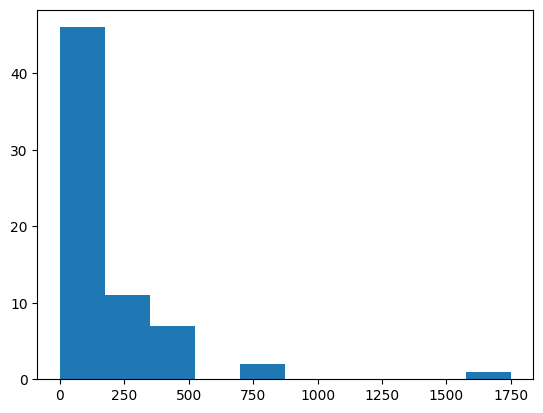

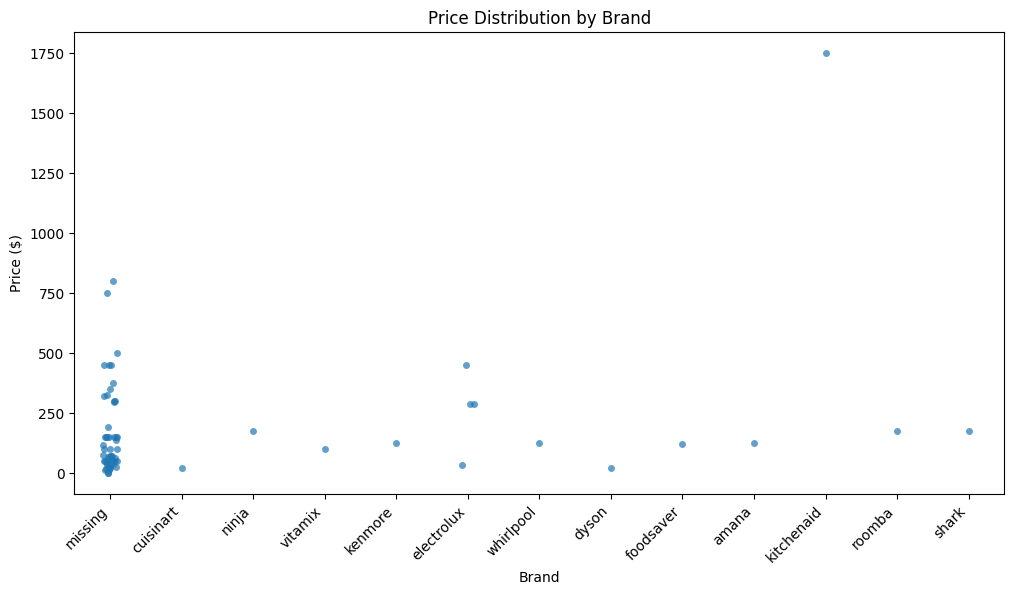

In [8]:
# explore the data and clean it
print(df['price'].describe())
df['price'].hist(grid=False)
plt.show()

plt.figure(figsize=(12,6))
ax = sns.stripplot(
    data=df,
    x='brand',
    y='price',
    jitter=True,
    alpha=0.7
)
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Price ($)')
plt.show()

This showed/confirmed there are A LOT of missings for brands. This makes sense  because when I looked at the wrangled data there were a lot of NaN for brand names. What this does show is that much of the prices are very similar, and you can see more variation in price among the missings. This probably means that these items for sale are different brands (and therefore different products and prices), but it just doesnt show it. I am going to try to use the listing date to get an age to do more investigation. A lot of the posts included an "age" but more in words like new, brand new, etc. so maybe that could give some insight - could turn it into a new/not new boolean with 0 and 1.

count                                     67
mean     2025-12-26 08:46:12.477612032+00:00
min                2025-08-11 11:51:00+00:00
25%         2025-12-14 05:31:29.500000+00:00
50%                2026-01-02 17:34:21+00:00
75%         2026-01-20 04:35:09.500000+00:00
max                2026-02-01 20:01:21+00:00
Name: posted date, dtype: object


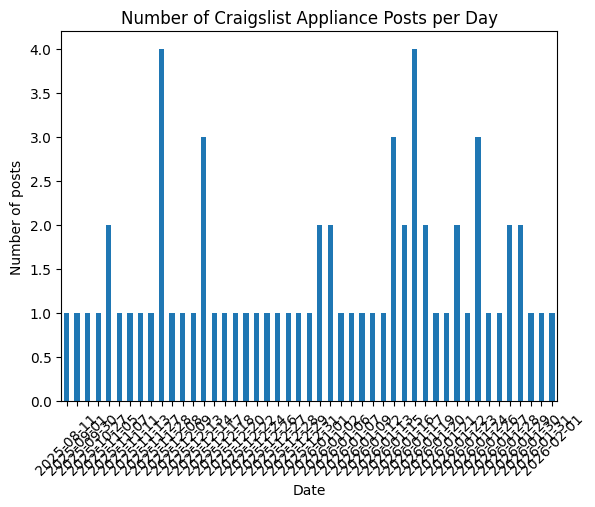

In [11]:
df['posted date'] = pd.to_datetime(df['posted date'], utc=True, errors='coerce')
df['posted date'].dtype
print(df['posted date'].describe())
df['post_day'] = df['posted date'].dt.date
df['post_day'].value_counts().sort_index().plot(kind='bar')
plt.ylabel('Number of posts')
plt.xlabel('Date')
plt.title('Number of Craigslist Appliance Posts per Day')
plt.xticks(rotation=45)
plt.show()

This tells me there is not really much pattern to it, but it is interesting to look at how the dates change. I would have expected a seasonal trend which you sort of see, but not as much as expected. I think this likely has to do with the lack of volume from this data set. Many of the data were missings, etc. so it is not very robust which may lead to a lack of trend. Last, I am going to look and see if newer listings have higher prices. In a lot of resale sights, prices tend to go down as theyve been online for longer just because they are not having success in selling.

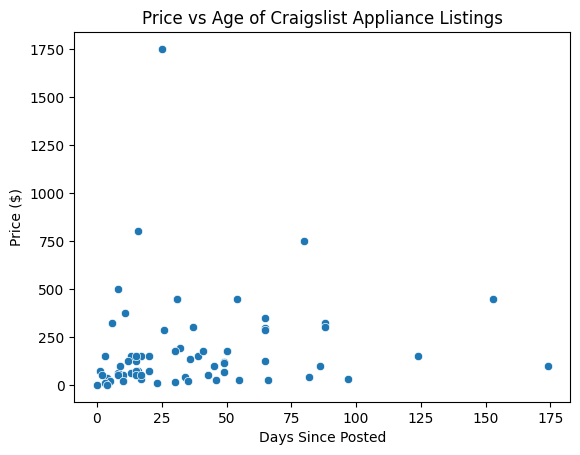

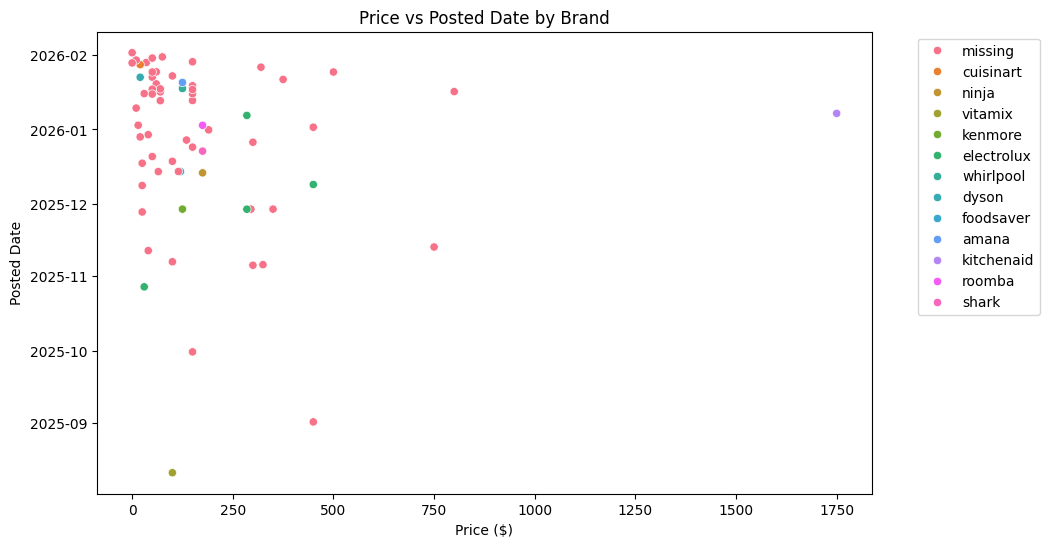

In [13]:
# listing age var.
df['days_since_posted'] = (pd.Timestamp.utcnow() - df['posted date']).dt.days
sns.scatterplot(data=df, x='days_since_posted', y='price')
plt.xlabel('Days Since Posted')
plt.ylabel('Price ($)')
plt.title('Price vs Age of Craigslist Appliance Listings')
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='price', y='posted date', hue='brand')
plt.xlabel('Price ($)')
plt.ylabel('Posted Date')
plt.title('Price vs Posted Date by Brand')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

This sort of shows that there isnt a crazy trend between these two things. I am wondering if we expanded this outside of charlottesville to bigger cities and did a 3 way plot that we might see more information. There just looks to be more data points that were posted more recently, which may also mean that older posts may be deleted after a while, which would completely eliminate anything we might see with this.

I think that this is a good start to EDA of appliance listings on craigslist. Moving forward, I would expand the radius to reach outside of charlottesville in hopes of having higher numbers of data to potentially create better visualizations.